# Análise de Padrões de Comportamento de Compra de Clientes

## Objetivo

Analisar uma base de dados simulada de compras com o objetivo de identificar padrões de comportamento dos clientes considerando características como idade, sexo, produto comprado, preço, horário e dia da semana.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tabela_Dados = {
    "ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Nome" : ["Amanda", "Bruno", "Carla", "Daniel", "Elisa", "Felipe", "Gabriela", "Henrique", "Isabela", "Jorge"],
    "Idade": [25, 39, 46, 19, 31, 55, 22, 28, 35, 42],
    "Sexo": ["F", "M", "F", "M", "F", "M", "F", "M", "F", "M"],
        "Produto": [
        "Fones de ouvido",
        "Camiseta esportiva",
        "Notebook",
        "Mouse gamer",
        "Perfume importado",
        'Televisão 50"',
        "Bolsa de couro",
        "Tênis casual",
        "Livro de negócios",
        "Relógio esportivo"
        ],
    "Preco": [150.00, 89.90, 3500.00, 210.00, 250.00, 2700.00, 370.00, 280.00, 59.90, 520.00],
    "Horario": [
        "18:45", "08:10", "14:20", "22:30", "13:10",
        "11:50", "17:40", "20:00", "09:35", "19:25"
    ],
        "Dia_Semana": [
        "Terça-feira",
        "Sábado",
        "Quarta-feira",
        "Sexta-feira",
        "Segunda-feira",
        "Domingo",
        "Terça-feira",
        "Sexta-feira",
        "Quarta-feira",
        "Quinta-feira"
    ]
}

df = pd.DataFrame(tabela_Dados)
df

,ID,Nome,Idade,Sexo,Produto,Preco,Horario,Dia_Semana
0,1,Amanda,25,F,Fones de ouvido,150.0,18:45,Terça-feira
1,2,Bruno,39,M,Camiseta esportiva,89.9,08:10,Sábado
2,3,Carla,46,F,Notebook,3500.0,14:20,Quarta-feira
3,4,Daniel,19,M,Mouse gamer,210.0,22:30,Sexta-feira
4,5,Elisa,31,F,Perfume importado,250.0,13:10,Segunda-feira
5,6,Felipe,55,M,"Televisão 50""",2700.0,11:50,Domingo
6,7,Gabriela,22,F,Bolsa de couro,370.0,17:40,Terça-feira
7,8,Henrique,28,M,Tênis casual,280.0,20:00,Sexta-feira
8,9,Isabela,35,F,Livro de negócios,59.9,09:35,Quarta-feira
9,10,Jorge,42,M,Relógio esportivo,520.0,19:25,Quinta-feira


In [48]:
print("===== INFORMAÇÕES DA BASE =====")
df.info()

print("\n===== ESTATÍSTICAS DESCRITIVAS =====")
print(df.describe())

print("\n===== QUANTIDADE DE CLIENTES POR SEXO =====")
print(df["Sexo"].value_counts())

print("\n===== VALOR MÉDIO DAS COMPRAS POR SEXO =====")
print(df.groupby("Sexo")["Preco"].mean())

print("\n===== MENOR E MAIOR COMPRA =====")
print(f"Menor compra: R$ {df['Preco'].min():.2f}")
print(f"Maior compra: R$ {df['Preco'].max():.2f}")

print("\n===== IDADE MÉDIA DOS CLIENTES =====")
print(f"Idade média: {df['Idade'].mean():.1f} anos")

print("\n===== PREÇO MÉDIO DAS COMPRAS =====")
print(f"Preço médio: R$ {df['Preco'].mean():.2f}")

===== INFORMAÇÕES DA BASE =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10 non-null     int64  
 1   Nome        10 non-null     object 
 2   Idade       10 non-null     int64  
 3   Sexo        10 non-null     object 
 4   Produto     10 non-null     object 
 5   Preco       10 non-null     float64
 6   Horario     10 non-null     object 
 7   Dia_Semana  10 non-null     object 
dtypes: float64(1), int64(2), object(5)
memory usage: 772.0+ bytes

===== ESTATÍSTICAS DESCRITIVAS =====
             ID      Idade        Preco
count  10.00000  10.000000    10.000000
mean    5.50000  34.200000   812.980000
std     3.02765  11.399805  1227.332483
min     1.00000  19.000000    59.900000
25%     3.25000  25.750000   165.000000
50%     5.50000  33.000000   265.000000
75%     7.75000  41.250000   482.500000
max    10.00000  55.000000  3500

In [49]:
df["Faixa_Etaria"] = pd.cut(
    df["Idade"],
    bins=[0, 25, 40, 60],
    labels=["Jovens", "Adultos", "Mais de 40"]
)

print("===== CLIENTES POR FAIXA ETÁRIA =====")
print(df["Faixa_Etaria"].value_counts().sort_index())

print("\n===== IDADE MÉDIA POR FAIXA ETÁRIA =====")
print(df.groupby("Faixa_Etaria", observed=True)["Idade"].mean())

print("\n===== PREÇO MÉDIO DAS COMPRAS POR FAIXA ETÁRIA =====")
print(
    df.groupby("Faixa_Etaria", observed=True)["Preco"]
      .mean()
      .round(2)
)

print("\n===== PRODUTOS COMPRADOS POR FAIXA ETÁRIA =====")
for faixa, grupo in df.groupby("Faixa_Etaria", observed=True):
    print(f"\n{faixa}:")
    print(grupo[["Nome", "Idade", "Produto", "Preco"]].to_string(index=False))

===== CLIENTES POR FAIXA ETÁRIA =====
Faixa_Etaria
Jovens        3
Adultos       4
Mais de 40    3
Name: count, dtype: int64

===== IDADE MÉDIA POR FAIXA ETÁRIA =====
Faixa_Etaria
Jovens        22.000000
Adultos       33.250000
Mais de 40    47.666667
Name: Idade, dtype: float64

===== PREÇO MÉDIO DAS COMPRAS POR FAIXA ETÁRIA =====
Faixa_Etaria
Jovens         243.33
Adultos        169.95
Mais de 40    2240.00
Name: Preco, dtype: float64

===== PRODUTOS COMPRADOS POR FAIXA ETÁRIA =====

Jovens:
    Nome  Idade         Produto  Preco
  Amanda     25 Fones de ouvido  150.0
  Daniel     19     Mouse gamer  210.0
Gabriela     22  Bolsa de couro  370.0

Adultos:
    Nome  Idade            Produto  Preco
   Bruno     39 Camiseta esportiva   89.9
   Elisa     31  Perfume importado  250.0
Henrique     28       Tênis casual  280.0
 Isabela     35  Livro de negócios   59.9

Mais de 40:
  Nome  Idade           Produto  Preco
 Carla     46          Notebook 3500.0
Felipe     55     Televisão 50" 27

In [50]:

df["Hora"] = pd.to_datetime(df["Horario"], format="%H:%M").dt.hour


df["Periodo"] = pd.cut(
    df["Hora"],
    bins=[0, 12, 18, 24],
    labels=["Manhã", "Tarde", "Noite"],
    right=False
)

print("===== CLIENTES POR PERÍODO DO DIA =====")
print(df["Periodo"].value_counts().sort_index())

print("\n===== PREÇO MÉDIO DAS COMPRAS POR PERÍODO =====")
print(
    df.groupby("Periodo", observed=True)["Preco"]
      .mean()
      .round(2)
)

print("\n===== PRODUTOS COMPRADOS POR PERÍODO =====")

for periodo, grupo in df.groupby("Periodo", observed=True):
    print(f"\n{periodo}:")
    print(
        grupo[["Nome", "Horario", "Produto", "Preco"]]
        .sort_values("Horario")
        .to_string(index=False)
    )

===== CLIENTES POR PERÍODO DO DIA =====
Periodo
Manhã    3
Tarde    3
Noite    4
Name: count, dtype: int64

===== PREÇO MÉDIO DAS COMPRAS POR PERÍODO =====
Periodo
Manhã     949.93
Tarde    1373.33
Noite     290.00
Name: Preco, dtype: float64

===== PRODUTOS COMPRADOS POR PERÍODO =====

Manhã:
   Nome Horario            Produto  Preco
  Bruno   08:10 Camiseta esportiva   89.9
Isabela   09:35  Livro de negócios   59.9
 Felipe   11:50      Televisão 50" 2700.0

Tarde:
    Nome Horario           Produto  Preco
   Elisa   13:10 Perfume importado  250.0
   Carla   14:20          Notebook 3500.0
Gabriela   17:40    Bolsa de couro  370.0

Noite:
    Nome Horario           Produto  Preco
  Amanda   18:45   Fones de ouvido  150.0
   Jorge   19:25 Relógio esportivo  520.0
Henrique   20:00      Tênis casual  280.0
  Daniel   22:30       Mouse gamer  210.0


In [51]:
print("===== QUANTIDADE DE CLIENTES POR SEXO E FAIXA ETÁRIA =====")
print(
    pd.crosstab(
        df["Faixa_Etaria"],
        df["Sexo"]
    )
)

print("\n===== VALOR MÉDIO DAS COMPRAS POR SEXO =====")
print(
    df.groupby("Sexo")["Preco"]
      .mean()
      .round(2)
)

print("\n===== PRODUTOS COMPRADOS POR MULHERES =====")
mulheres = df[df["Sexo"] == "F"]
print(
    mulheres[
        ["Nome", "Idade", "Faixa_Etaria", "Produto", "Preco"]
    ].to_string(index=False)
)

print("\n===== PRODUTOS COMPRADOS POR HOMENS =====")
homens = df[df["Sexo"] == "M"]
print(
    homens[
        ["Nome", "Idade", "Faixa_Etaria", "Produto", "Preco"]
    ].to_string(index=False)
)

print("\n===== VALOR TOTAL DAS COMPRAS POR SEXO =====")
print(
    df.groupby("Sexo")["Preco"]
      .sum()
      .round(2)
)

print("\n===== RELAÇÃO ENTRE SEXO, FAIXA ETÁRIA E PRODUTO =====")
print(
    df[
        ["Nome", "Sexo", "Idade", "Faixa_Etaria", "Produto", "Preco"]
    ].to_string(index=False)
)

===== QUANTIDADE DE CLIENTES POR SEXO E FAIXA ETÁRIA =====
Sexo          F  M
Faixa_Etaria      
Jovens        2  1
Adultos       2  2
Mais de 40    1  2

===== VALOR MÉDIO DAS COMPRAS POR SEXO =====
Sexo
F    865.98
M    759.98
Name: Preco, dtype: float64

===== PRODUTOS COMPRADOS POR MULHERES =====
    Nome  Idade Faixa_Etaria           Produto  Preco
  Amanda     25       Jovens   Fones de ouvido  150.0
   Carla     46   Mais de 40          Notebook 3500.0
   Elisa     31      Adultos Perfume importado  250.0
Gabriela     22       Jovens    Bolsa de couro  370.0
 Isabela     35      Adultos Livro de negócios   59.9

===== PRODUTOS COMPRADOS POR HOMENS =====
    Nome  Idade Faixa_Etaria            Produto  Preco
   Bruno     39      Adultos Camiseta esportiva   89.9
  Daniel     19       Jovens        Mouse gamer  210.0
  Felipe     55   Mais de 40      Televisão 50" 2700.0
Henrique     28      Adultos       Tênis casual  280.0
   Jorge     42   Mais de 40  Relógio esportivo  520.0



In [52]:
print("===== QUANTIDADE DE COMPRAS POR DIA =====")
print(
    df["Dia_Semana"]
    .value_counts()
    .to_string()
)

print("\n===== VALOR MÉDIO DAS COMPRAS POR DIA =====")
print(
    df.groupby("Dia_Semana")["Preco"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .to_string()
)

print("\n===== VALOR TOTAL DAS COMPRAS POR DIA =====")
print(
    df.groupby("Dia_Semana")["Preco"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .to_string()
)

print("\n===== COMPRAS REALIZADAS EM CADA DIA =====")

for dia, grupo in df.groupby("Dia_Semana"):
    print(f"\n--- {dia} ---")
    print(
        grupo[["Nome", "Sexo", "Idade", "Produto", "Preco"]]
        .to_string(index=False)
    )

===== QUANTIDADE DE COMPRAS POR DIA =====
Dia_Semana
Terça-feira      2
Quarta-feira     2
Sexta-feira      2
Sábado           1
Segunda-feira    1
Domingo          1
Quinta-feira     1

===== VALOR MÉDIO DAS COMPRAS POR DIA =====
Dia_Semana
Domingo          2700.00
Quarta-feira     1779.95
Quinta-feira      520.00
Terça-feira       260.00
Segunda-feira     250.00
Sexta-feira       245.00
Sábado             89.90

===== VALOR TOTAL DAS COMPRAS POR DIA =====
Dia_Semana
Quarta-feira     3559.9
Domingo          2700.0
Quinta-feira      520.0
Terça-feira       520.0
Sexta-feira       490.0
Segunda-feira     250.0
Sábado             89.9

===== COMPRAS REALIZADAS EM CADA DIA =====

--- Domingo ---
  Nome Sexo  Idade       Produto  Preco
Felipe    M     55 Televisão 50" 2700.0

--- Quarta-feira ---
   Nome Sexo  Idade           Produto  Preco
  Carla    F     46          Notebook 3500.0
Isabela    F     35 Livro de negócios   59.9

--- Quinta-feira ---
 Nome Sexo  Idade           Produto  Pr

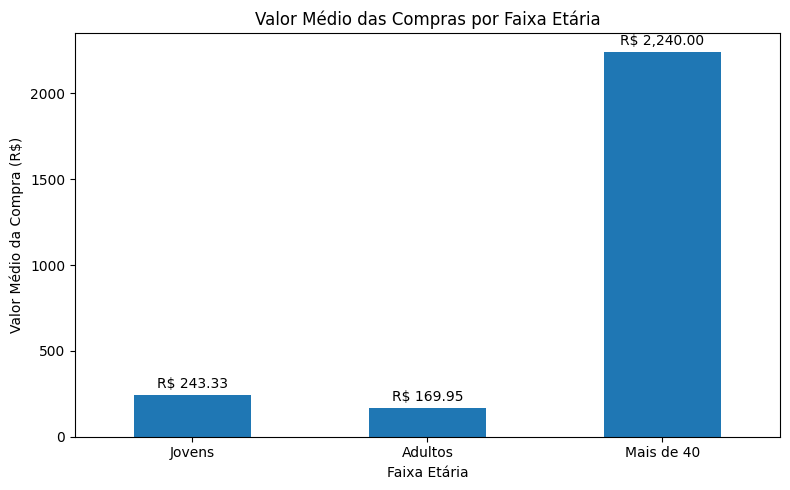

In [53]:
media_faixa = (
    df.groupby("Faixa_Etaria", observed=True)["Preco"]
    .mean()
)

ax = media_faixa.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Valor Médio das Compras por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Valor Médio da Compra (R$)")
plt.xticks(rotation=0)

for i, valor in enumerate(media_faixa):
    ax.text(
        i,
        valor + 40,
        f"R$ {valor:,.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [54]:
print("===== RESUMO DOS PADRÕES IDENTIFICADOS =====")

print("\n1. FAIXA ETÁRIA")
print(
    df.groupby("Faixa_Etaria", observed=True)["Preco"]
    .mean()
    .round(2)
)

print("\n2. PERÍODO DO DIA")
print(
    df.groupby("Periodo", observed=True)["Preco"]
    .mean()
    .round(2)
)

print("\n3. SEXO")
print(
    df.groupby("Sexo")["Preco"]
    .mean()
    .round(2)
)

print("\n4. TOTAL DE CLIENTES")
print(f"{len(df)} clientes")

print("\n5. IDADE MÉDIA")
print(f"{df['Idade'].mean():.1f} anos")

print("\n6. VALOR MÉDIO DAS COMPRAS")
print(f"R$ {df['Preco'].mean():.2f}")

===== RESUMO DOS PADRÕES IDENTIFICADOS =====

1. FAIXA ETÁRIA
Faixa_Etaria
Jovens         243.33
Adultos        169.95
Mais de 40    2240.00
Name: Preco, dtype: float64

2. PERÍODO DO DIA
Periodo
Manhã     949.93
Tarde    1373.33
Noite     290.00
Name: Preco, dtype: float64

3. SEXO
Sexo
F    865.98
M    759.98
Name: Preco, dtype: float64

4. TOTAL DE CLIENTES
10 clientes

5. IDADE MÉDIA
34.2 anos

6. VALOR MÉDIO DAS COMPRAS
R$ 812.98
